In [2]:
import numpy as np
import torch
torch.set_grad_enabled(False)
print("Disabled automatic differentiation")
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset
import matplotlib.pyplot as plt

import matplotlib.gridspec as gridspec
from tqdm.notebook import tqdm

from joblib import Parallel, delayed
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

from dadapy import data
from dadapy.data import Data
import scipy

from scipy import stats
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

from scipy.stats import linregress

import matplotlib.colors as mcolors
hex6 = ['#648FFF', '#785EF0', '#DC267F', '#FE6100', '#FFB000']
colors6=[mcolors.to_rgb(i) for i in hex6]
from scipy.spatial.distance import pdist, squareform

from dadapy.density_estimation import DensityEstimation


import sys
import os
sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from extract_id import extract_hidden_states, compute_ids, shuffle_tokens, convert_to_distances

# Use the GitHub version for CorrInt to work (pip install "git+https://github.com/scikit-learn-contrib/scikit-dimension.git")
import skdim 
import matplotlib.ticker as ticker
from sklearn.neighbors import NearestNeighbors




Disabled automatic differentiation


In [4]:
device = torch.device('cuda')
model_name = "meta-llama/Meta-Llama-3-8B"

model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
tokenizer = AutoTokenizer.from_pretrained(model_name)

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [5]:
filtered_indices = np.load('../filtered_indices.npy')
ds = load_dataset("NeelNanda/pile-10k")['train']
sequences = ds['text']
max_length = 1024

## Some utils

In [6]:
def shuffle_tokens(ids):
    assert ids.shape[0] == 1 and len(ids.shape) == 2, f"Expected shape (1, N), but got {ids.shape}"
    permutation = np.random.permutation(ids.shape[1])
    return ids[:, permutation]

def convert_to_distances(hs):
    return torch.stack([torch.cdist(item, item).squeeze() for item in hs])

def convert_to_tensor(hs):
    return torch.stack([item for item in hs])

def extract_hidden_states(sequence, model, tokenizer, max_length, return_logits = False):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    inputs = tokenizer(sequence.strip() , add_special_tokens = False, \
                     return_tensors = "pt", max_length = max_length, \
                         truncation=True).to(device)
    outputs = model(**inputs, labels = inputs['input_ids'].clone(), \
                  output_hidden_states=True)
    hidden_states, loss = outputs.hidden_states, outputs.loss
    ans = {
            "hidden_distances" : convert_to_distances(hidden_states),\
        
          "hidden_states" : convert_to_tensor(hidden_states),\
          "loss": loss.to(torch.float32).cpu().detach().numpy(), \
          # "logit_distances": torch.cdist(outputs.logits, outputs.logits).cpu().detach().numpy().squeeze()
         }
    if return_logits: ans["logits"] = outputs.logits
    return ans

In [7]:
def plot_ids_line_comparison(all_ids, all_shuffled_ids, methods):
    # Set up the figure
    plt.figure(figsize=(10, 7))
    
    # Get the number of methods for grid layout
    n_methods = len(methods)
    n_cols = 3  # Number of columns in the grid
    n_rows = (n_methods + n_cols - 1) // n_cols  # Calculate needed rows
    
    # Plot each method in a separate subplot
    for i, method in enumerate(methods, 1):
        ax = plt.subplot(n_rows, n_cols, i)
        
        # Plot original IDs
        if method in all_ids:
            original_ids = all_ids[method]
            x_vals = np.arange(len(original_ids))
            ax.plot(x_vals, original_ids, 'b-', label='Original', linewidth=2)
            

        
        # Plot shuffled IDs
        if method in all_shuffled_ids:
            shuffled_ids = all_shuffled_ids[method]
            x_vals = np.arange(len(shuffled_ids))
            ax.plot(x_vals, shuffled_ids, 'r-', label='Shuffled', linewidth=2)

        
        # Set the title and labels
        ax.set_title(f'{method}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Layers')
        ax.set_ylabel('Intrinsic Dimension')
        
        # Add grid and legend
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(loc='best')
        
        # Adjust y-axis to ensure both lines are visible
        if method in all_ids and method in all_shuffled_ids:
            all_values = np.concatenate([original_ids, shuffled_ids])
            y_min = max(0, np.min(all_values) * 0.9)  # Ensure no negative values
            y_max = np.max(all_values) * 1.1  # Add 10% margin
            ax.set_ylim(y_min, y_max)
    
    # Add a global title
    plt.suptitle(f'Intrinsic Dimension Estimates: Unshuffled vs. Shuffled Tokens for prompt {filtered_indices[PNUM]}', 
                fontsize=16, fontweight='bold', y=0.98)
    
    # Adjust layout
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    return plt

In [8]:
METHODS = {
    'lPCA': None,
    'CorrInt': None,
    'FisherS': None,
    'MLE': skdim.id.MLE(),
    'TLE': skdim.id.TLE(),
    'ESS': skdim.id.ESS(),
    'MOM': skdim.id.MOM(),
    'GRIDE': None
}

def get_knn_from_torch_distance_matrix(dist_matrix: torch.Tensor, k: int):
    """
    dist_matrix: torch.Tensor of shape (N, N) — pairwise distances
    k: number of nearest neighbors to extract (excluding self-distance)

    Returns:
        knn_dists: np.ndarray of shape (N, k) with distances to k nearest neighbors
    """
    assert dist_matrix.shape[0] == dist_matrix.shape[1], "Distance matrix must be square"
    
    # Exclude the self-distance (0) by sorting and skipping the first column
    sorted_dists, sorted_neighbors = torch.sort(dist_matrix, dim=1)
    # print(sorted_neighbors)
    knn_dists = sorted_dists[:, 1:k+1]  # Exclude self (first entry)
    
    return sorted_dists[:, 1:k+1], sorted_neighbors[:, 1:k+1]  # Only this small part is moved to CPU

def compute_id_sigle_point_cloud(rep, dist_matrix, method):
    
    if method == 'lPCA':
        # knn_dists, knn_neighbors = get_knn_from_torch_distance_matrix(dist_matrix, k=4)
        # # print(knn_dists)
        # knn_dists, knn_neighbors = knn_dists.double().cpu().numpy(), knn_neighbors.cpu().numpy()
        lPCA = skdim.id.lPCA()
        lid = lPCA.fit_pw(rep.double().cpu().numpy()[1:],n_neighbors=64).dimension_pw_
        return lid.mean()
    
    if method == 'CorrInt':
        # knn_dists, knn_neighbors = get_knn_from_torch_distance_matrix(dist_matrix, k=4)
        # # print(knn_dists)
        # knn_dists, knn_neighbors = knn_dists.double().cpu().numpy(), knn_neighbors.cpu().numpy()
        corr_int = skdim.id.CorrInt(k1 = 2, k2 = 4, DM = False)
        return corr_int.fit_transform(rep.cpu().numpy())

    if method == 'FisherS':
        # knn_dists, knn_neighbors = get_knn_from_torch_distance_matrix(dist_matrix, k=4)
        # # print(knn_dists)
        # knn_dists, knn_neighbors = knn_dists.double().cpu().numpy(), knn_neighbors.cpu().numpy()
        fisherS = skdim.id.FisherS()
        return fisherS.fit_transform(rep.double().cpu().numpy()[1:])
    
    if method == 'ESS':
        knn_dists, knn_neighbors = get_knn_from_torch_distance_matrix(dist_matrix, k=4)
        # print(knn_dists)
        knn_dists, knn_neighbors = knn_dists.double().cpu().numpy(), knn_neighbors.cpu().numpy()
        ess=skdim.id.ESS()
        return ess.fit_transform(rep.cpu().numpy(), precomputed_knn_arrays=[knn_dists, knn_neighbors])
        
    # elif method == 'PCA':
    #     pca=skdim.id.lPCA()
    #     # return pca.fit_pw(rep).dimension_pw_
    #     return pca.fit_transform(rep.double().cpu().numpy())
    
    elif method == 'MADA':
        # knn_dists, knn_neighbors = get_knn_from_torch_distance_matrix(dist_matrix, k=10)
        # knn_dists, knn_neighbors = knn_dists.double().cpu().numpy(), knn_neighbors.cpu().numpy()
        mada = skdim.id.MADA()
        return mada.fit_transform(rep.double().cpu().numpy())

    elif method == 'TLE':
        knn_dists, knn_neighbors = get_knn_from_torch_distance_matrix(dist_matrix, k=10)
        knn_dists, knn_neighbors = knn_dists.double().cpu().numpy(), knn_neighbors.cpu().numpy()
        tle = skdim.id.TLE()
        return tle.fit_transform(rep.double().cpu().numpy(), precomputed_knn_arrays=[knn_dists, knn_neighbors], n_jobs = -1)

    elif method == 'MLE':
        # knn_dists, knn_neighbors = get_knn_from_torch_distance_matrix(dist_matrix, k=5)
        # knn_dists, knn_neighbors = knn_dists.double().cpu().numpy(), knn_neighbors.cpu().numpy()
        mle = skdim.id.MLE()
        return mle.fit_transform(rep.double().cpu().numpy(), n_jobs = -1)
    
    elif method == 'GRIDE':
        _data = data.Data(distances=dist_matrix.cpu().numpy(), maxk=100)
        return _data.return_id_scaling_gride(range_max=64)[0][1]
    
    else:
        # print("Hi")
        return METHODS[method].fit_transform(rep.double().cpu().numpy())
    
    
def compute_ids(full_reps, full_distances, method):
    ids = []
    # Create a tqdm progress bar for the zip of full_reps and full_distances
    # Starting from index 1 for both iterables
    for rep, distance in tqdm(zip(full_reps[1:], full_distances[1:]), 
                             total=len(full_reps)-1,  # Set total to length-1 since we're skipping first element
                             desc=f"Computing IDs for {method}",    # Description for the progress bar
                             unit="sample"):          # Unit name
        ids.append(compute_id_sigle_point_cloud(rep, distance, method))
    return np.array(ids)

## Comparison

In [9]:
PNUM = 686 # prompt number 3218

In [10]:
sequence = sequences[filtered_indices[PNUM]]
ans = extract_hidden_states(sequence, model, tokenizer, max_length)
hidden_distances = ans['hidden_distances'].squeeze()
hidden_states = ans['hidden_states'].squeeze()

In [11]:
inputs = tokenizer(sequence.strip(), add_special_tokens=False, return_tensors="pt",
                                       max_length=max_length, truncation=True).to(device)
ids = inputs['input_ids']
new_ids = shuffle_tokens(ids).to(device)
inputs = {'input_ids':new_ids}
outputs = model(**inputs, labels = inputs['input_ids'].clone(), output_hidden_states=True)
hidden_shuffled_distances = convert_to_distances(outputs.hidden_states).squeeze()
hidden_shuffled_states = convert_to_tensor(outputs.hidden_states).squeeze()

In [12]:
# lPCA takes a lot of time!!
all_ids = {}
all_shuffled_ids = {}
for method in METHODS:
    all_ids[method] = compute_ids(hidden_states, hidden_distances, method)
    all_shuffled_ids[method] = compute_ids(hidden_shuffled_states, hidden_shuffled_distances, method)

Computing IDs for lPCA:   0%|          | 0/32 [00:00<?, ?sample/s]

Computing IDs for lPCA:   0%|          | 0/32 [00:00<?, ?sample/s]

Computing IDs for CorrInt:   0%|          | 0/32 [00:00<?, ?sample/s]

Computing IDs for CorrInt:   0%|          | 0/32 [00:00<?, ?sample/s]

Computing IDs for FisherS:   0%|          | 0/32 [00:00<?, ?sample/s]

...

Computing IDs for ESS:   0%|          | 0/32 [00:00<?, ?sample/s]

Computing IDs for MOM:   0%|          | 0/32 [00:00<?, ?sample/s]

Computing IDs for MOM:   0%|          | 0/32 [00:00<?, ?sample/s]

Computing IDs for GRIDE:   0%|          | 0/32 [00:00<?, ?sample/s]

Computing IDs for GRIDE:   0%|          | 0/32 [00:00<?, ?sample/s]

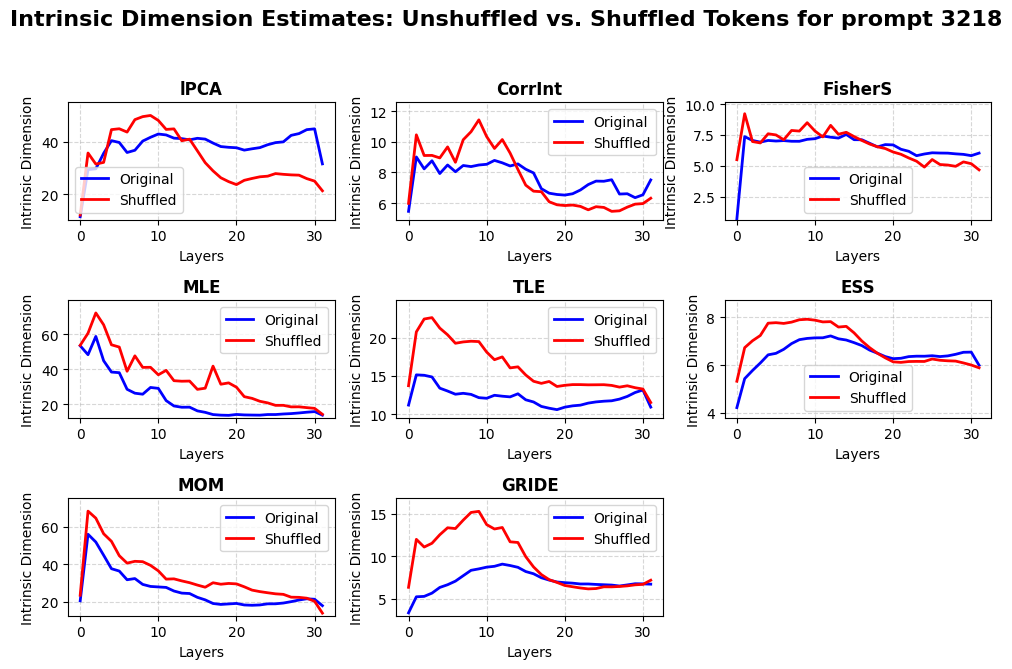

In [13]:
# Usage:
fig = plot_ids_line_comparison(all_ids, all_shuffled_ids, list(METHODS.keys()))
# plt.savefig('plots/id_estimators_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## DO NOT LOOK HERE

### Analyzing test prompt

In [8]:
PNUM = 686 # prompt number 3218

In [9]:
sequence = sequences[filtered_indices[PNUM]]
ans = extract_hidden_states(sequence, model, tokenizer, max_length, return_logits = True)
hidden_distances = ans['hidden_distances'].squeeze()
hidden_states = ans['hidden_states'].squeeze()
logits = ans['logits'].squeeze()

In [23]:
from sklearn.utils.validation import check_array, check_is_fitted
def get_nn(X, k, n_jobs=1):
    """Compute the k-nearest neighbors of a dataset np.array (n_samples x n_dims)"""
    neigh = NearestNeighbors(n_neighbors=k, n_jobs=n_jobs)
    neigh.fit(X)
    dists, inds = neigh.kneighbors(return_distance=True)
    return dists, inds
    
def fit_transform_pw_monkey(
    self, X, precomputed_knn=None, smooth=False, n_neighbors=100, n_jobs=1
):
    X = check_array(X, ensure_min_samples=n_neighbors + 1, ensure_min_features=2)

    if precomputed_knn is not None:
        knnidx = precomputed_knn
    else:
        _, knnidx = get_nn(X, k=n_neighbors, n_jobs=n_jobs)

    if n_jobs > 1:
        def fit_estimator(data_slice):
            return self.fit(data_slice).dimension_
        results = Parallel(n_jobs=n_jobs)(
            delayed(fit_estimator)(X[i, :]) for i in tqdm(knnidx)
        )
        dimension_pw_ = np.array(results)
    else:
        dimension_pw_ = np.array([self.fit(X[i, :]).dimension_ for i in knnidx])

    if smooth:
        dimension_pw_smooth_ = np.zeros(len(knnidx))
        for i, point_nn in enumerate(knnidx):
            dimension_pw_smooth_[i] = np.mean(
                np.append(dimension_pw_[i], dimension_pw_[point_nn])
            )
        return dimension_pw_, dimension_pw_smooth_
    else:
        return dimension_pw_

In [24]:
from sklearn.decomposition import PCA
lPCA = skdim.id.lPCA()

In [25]:
class MyLPCA(skdim.id.lPCA):
    fit_transform_pw = fit_transform_pw_monkey  # reuse the function defined above
class MyFisher(skdim.id.FisherS):
    fit_transform_pw = fit_transform_pw_monkey  # reuse the function defined above

In [45]:
X = hidden_states[-1].cpu().numpy()
n_components = 10                           # or any k ≤ hdim
pca = PCA(n_components=n_components, whiten=True, random_state=0)
X_proj = pca.fit_transform(X)  
explained_vars = pca.explained_variance_
# print("Explained variance:", explained_vars)
print("Implied side lengths:", np.sqrt(12 * explained_vars)/np.sqrt(12 * explained_vars)[0])

# lPCA = skdim.id.lPCA()
# print("PCA dimension = ", lPCA.fit_transform(X))

corr_int = skdim.id.CorrInt(k1 = 2, k2 = 4)
print("CorrInt dimension = ", corr_int.fit_transform(X))
est = MyLPCA(ver = 'Fan')
# fisherS = skdim.id.FisherS()
local_ce_dims = est.fit_transform_pw(X, n_jobs = 16, n_neighbors = 100)
print("Local PCA dimensions = ", local_ce_dims)

Implied side lengths: [1.   0.71 0.64 0.53 0.47 0.46 0.45 0.43 0.38 0.36]
CorrInt dimension =  7.5112581213793606


  0%|          | 0/100 [00:00<?, ?it/s]

Local PCA dimensions =  [24 22 28 25 23 26 26 22 28 23 24 30 30 23 20 21 19 23 23 20 15 20 16 16
 16 20 22 19 30 26 30 25 23 26 29 28 28 22 21 22 24 22 27 23 23 20 21 21
 26 22 22 20 20 20 15 20 16 16 16 21 25 24 21 28 25 25 26 23 21 26 23 21
 22 21 22 20 22 20 15 19 16 16 15 20 27 24 25 31 25 24 22 26 23 24 24 22
 23 23 24 24]


In [85]:
local_ce_dims

array([4.51, 4.3 , 4.47, ..., 6.66, 6.14, 6.26])

In [34]:
X = logits.cpu().numpy()
n_components = 10                           # or any k ≤ hdim
pca = PCA(n_components=n_components, whiten=True, random_state=0)
X_proj = pca.fit_transform(X)  
explained_vars = pca.explained_variance_
# print("Explained variance:", explained_vars)
print("Implied side lengths:", np.sqrt(12 * explained_vars)/np.sqrt(12 * explained_vars)[0])
# lPCA = skdim.id.lPCA()
# lPCA.fit_transform(X)

corr_int = skdim.id.CorrInt(k1 = 2, k2 = 4)
print("CorrInt dimension = ", corr_int.fit_transform(X))
# fisherS = skdim.id.FisherS()
# print("FisherS dimension = ", local_ce_dims)

Implied side lengths: [1.   0.38 0.34 0.22 0.2  0.19 0.17 0.16 0.15 0.15]
CorrInt dimension =  7.227354542158856


In [44]:
X = logits.cpu().numpy()
est = MyLPCA(ver = 'Fan')
local_logit_dims = est.fit_transform_pw(X, n_jobs = 16, n_neighbors = 100)
local_logit_dims 

  0%|          | 0/100 [00:00<?, ?it/s]

array([27, 27, 30, 29, 27, 31, 33, 30, 31, 23, 31, 31, 35, 22, 19, 27, 20,
       20, 22, 19, 18, 20, 14, 14, 10, 24, 21, 19, 34, 21, 25, 25, 21, 29,
       30, 33, 33, 23, 26, 31, 28, 32, 33, 23, 22, 22, 20, 26, 26, 23, 30,
       17, 18, 21, 18, 20, 16, 15, 10, 24, 25, 22, 28, 28, 28, 33, 31, 21,
       22, 30, 21, 20, 25, 22, 19, 19, 21, 19, 18, 21, 16, 13, 10, 24, 33,
       27, 33, 33, 26, 22, 26, 27, 28, 24, 22, 21, 22, 33, 29, 23])

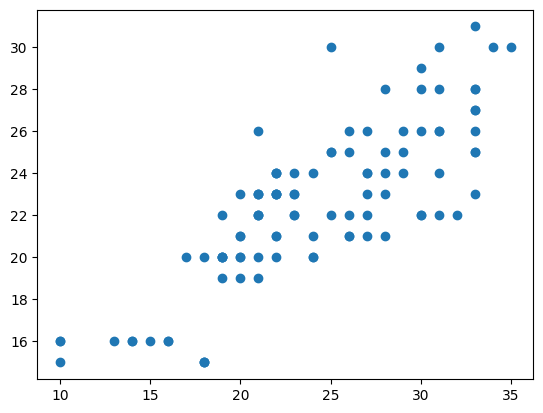

In [46]:
plt.scatter(local_logit_dims, local_ce_dims)

### Fisher Separability

In [52]:
X = logits.cpu().numpy()
est = MyFisher()
local_logit_dims = est.fit_transform_pw(X, n_jobs = 16, n_neighbors = 100)
local_logit_dims 

  0%|          | 0/100 [00:00<?, ?it/s]

array([5.61, 5.14, 5.3 , 5.3 , 5.16, 5.46, 6.2 , 5.33, 5.73, 4.75, 5.57,
       5.87, 6.48, 4.8 , 4.8 , 5.53, 4.62, 4.64, 5.14, 4.53, 3.99, 4.56,
       3.98, 3.99, 3.38, 5.27, 4.62, 4.35, 6.26, 4.82, 5.19, 5.11, 4.73,
       5.4 , 5.73, 6.41, 5.73, 5.22, 5.06, 5.82, 5.92, 5.87, 5.87, 4.9 ,
       4.66, 4.95, 4.95, 5.46, 5.14, 5.27, 5.69, 4.2 , 4.46, 4.59, 4.01,
       4.59, 4.05, 4.11, 3.55, 4.88, 5.09, 4.64, 5.27, 5.3 , 5.4 , 5.77,
       5.5 , 4.73, 4.61, 5.53, 4.82, 4.99, 5.3 , 4.88, 4.46, 4.62, 4.8 ,
       4.66, 4.  , 4.86, 3.94, 3.68, 3.4 , 5.01, 5.82, 5.3 , 6.02, 5.97,
       5.09, 4.99, 5.16, 5.36, 5.57, 4.82, 4.99, 4.61, 4.71, 5.77, 5.69,
       5.11])

In [54]:
X = hidden_states[-1].cpu().numpy()
est = MyFisher()
local_ce_dims = est.fit_transform_pw(X, n_jobs = 16, n_neighbors = 100)
local_ce_dims 

  0%|          | 0/100 [00:00<?, ?it/s]

array([5.24, 5.14, 5.14, 5.46, 4.92, 5.69, 5.61, 5.4 , 5.5 , 4.78, 5.53,
       5.06, 5.11, 4.76, 4.71, 4.48, 4.  , 4.78, 4.53, 4.26, 3.76, 4.22,
       3.77, 4.03, 3.68, 4.2 , 4.11, 4.14, 4.5 , 5.01, 4.51, 4.21, 4.33,
       4.35, 4.67, 4.48, 4.28, 4.24, 4.48, 4.26, 4.61, 4.33, 4.22, 4.39,
       4.05, 3.98, 4.46, 4.16, 4.09, 4.48, 4.02, 4.3 , 4.24, 4.15, 3.63,
       4.27, 3.83, 4.08, 3.66, 4.24, 5.11, 4.88, 4.61, 5.92, 5.09, 4.75,
       4.99, 4.84, 4.9 , 4.95, 4.84, 4.64, 4.41, 4.1 , 4.64, 4.22, 4.41,
       4.09, 3.57, 4.24, 3.79, 4.07, 3.71, 4.27, 4.88, 4.54, 4.62, 5.65,
       4.78, 4.99, 4.97, 5.3 , 4.69, 4.71, 4.95, 5.06, 4.43, 4.51, 4.47,
       4.99])

In [59]:
local_logit_dims.mean(), local_ce_dims.mean()

(5.029262612760477, 4.551366580328923)

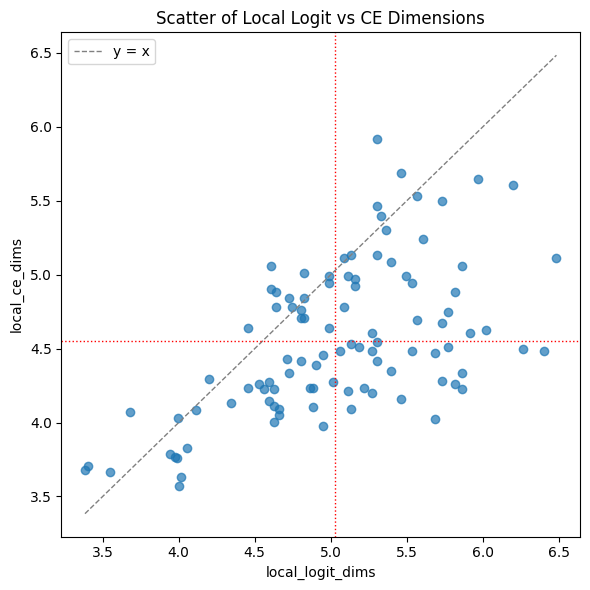

In [60]:
# plt.scatter(local_logit_dims, local_ce_dims)
min_val = min(local_logit_dims.min(), local_ce_dims.min())
max_val = max(local_logit_dims.max(), local_ce_dims.max())

# create the scatter + reference line
plt.figure(figsize=(6,6))
plt.scatter(local_logit_dims, local_ce_dims, alpha=0.7)
plt.plot([min_val, max_val],
         [min_val, max_val],
         linestyle='--', linewidth=1, color='gray',
         label='y = x')

# compute the means
mean_logit = np.mean(local_logit_dims)
mean_ce    = np.mean(local_ce_dims)
plt.axvline(mean_logit, color='red', linestyle=':', linewidth=1)
plt.axhline(mean_ce,    color='red', linestyle=':', linewidth=1)

# labels, title, legend
plt.xlabel('local_logit_dims')
plt.ylabel('local_ce_dims')
plt.title('Scatter of Local Logit vs CE Dimensions')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.plot(local_logit_dims - local_ce_dims)

In [25]:
explained_vars = pca.explained_variance_
# print("Explained variance:", explained_vars)
print("Implied side lengths:", np.sqrt(12 * explained_vars))

Implied side lengths: [149.17 105.1   94.88  78.44  70.57  68.66  67.67  63.73  56.98  54.43
  52.1   51.45  50.    49.53  46.3   45.79  45.09  43.14  42.16  41.95
  41.46  41.    40.4   39.41  39.17  38.2   37.28  36.86  36.23  35.88
  35.26  34.87  34.34  33.94  33.26  32.82  32.13  31.77  31.48  31.29
  30.98  30.35  30.24  30.07  29.8   29.18  28.85  28.63  28.42  28.29
  27.93  27.67  27.53  27.22  27.03  26.91  26.61  26.47  26.08  25.84
  25.65  25.38  25.17  25.15  24.9   24.84  24.65  24.43  24.39  24.24
  24.01  23.93  23.67  23.49  23.48  23.37  23.22  23.16  22.96  22.8
  22.63  22.58  22.48  22.31  22.26  22.21  21.84  21.8   21.64  21.45
  21.35  21.14  21.11  21.05  20.87  20.71  20.66  20.5   20.34  20.28]


In [17]:
# explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative:", np.cumsum(pca.explained_variance_ratio_))

print("Explained variance:", pca.explained_variance_)

Explained variance ratio: [0.09 0.05 0.04 0.03 0.02 0.02 0.02 0.02 0.01 0.01]
Cumulative: [0.09 0.14 0.18 0.2  0.22 0.24 0.26 0.28 0.29 0.31]
Explained variance: [1853.1   922.82  750.59  512.36  414.6   392.52  381.31  338.38  270.26
  246.67]


In [19]:
import numpy as np
from sklearn.decomposition import PCA

# Side lengths of the box
L = np.array([1, 2, 5, 0.5])  # 4D box
d = len(L)
n_samples = 10_000

# Uniform samples in [0, L_i]
X = np.random.rand(n_samples, d) * L

# Run PCA
pca = PCA()
pca.fit(X)
print(L**2/12)
print("Eigenvalues (variances):", pca.explained_variance_)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Expected ratios:", (L**2) / np.sum(L**2))

[0.08 0.33 2.08 0.02]
Eigenvalues (variances): [2.06 0.34 0.08 0.02]
Explained variance ratio: [0.82 0.14 0.03 0.01]
Expected ratios: [0.03 0.13 0.83 0.01]


### lPCA

In [14]:
X = hidden_states[10].cpu().numpy()

In [15]:
lPCA = skdim.id.lPCA()

In [34]:
lPCA.fit_transform(X[10:])

69

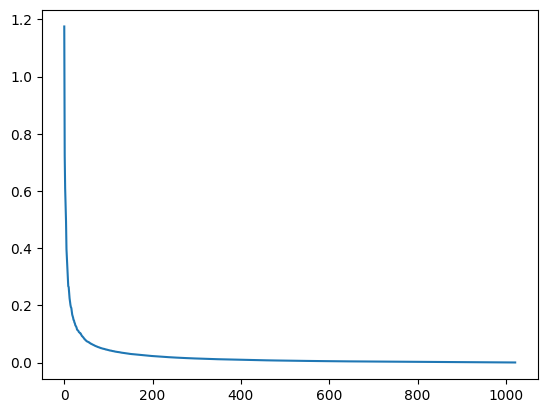

In [26]:
plt.plot(lPCA.explained_var_[1:-1])

### FisherS

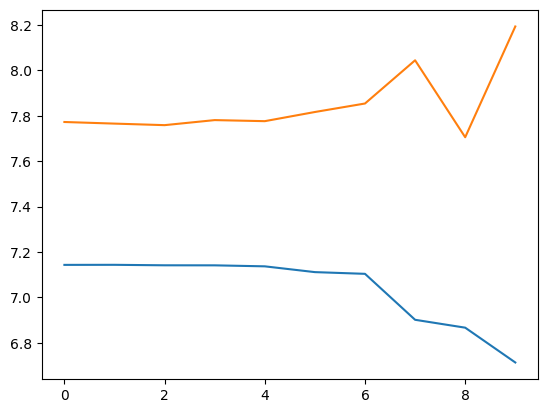

In [58]:
X = hidden_states[10].cpu().numpy()
fisherS = skdim.id.FisherS()

dX = [fisherS.fit_transform(X[2**idx:]) for idx in range(10)]
dY = [fisherS.fit_transform(Y[2**idx:]) for idx in range(10)]
plt.plot(dX)
plt.plot(dY)

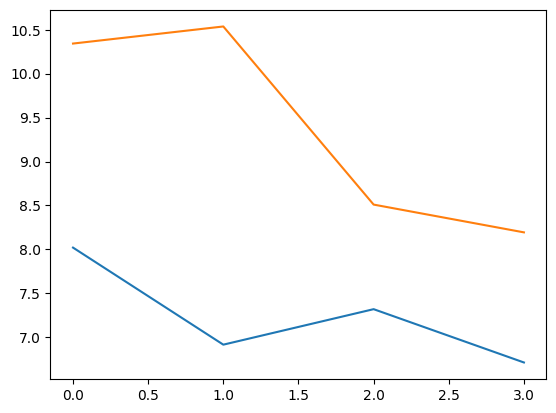

In [61]:
X = hidden_states[10].cpu().numpy()
fisherS = skdim.id.FisherS()

dX = [fisherS.fit_transform(X[-2**idx:]) for idx in range(6, 10)]
dY = [fisherS.fit_transform(Y[-2**idx:]) for idx in range(6, 10)]
plt.plot(dX)
plt.plot(dY)

In [56]:
Y = hidden_shuffled_states[10].cpu().numpy()
fisherS = skdim.id.FisherS()
fisherS.fit_transform(Y[512:])

8.193782724844265

In [69]:
method = 'FisherS'

In [70]:
ids = compute_ids(hidden_states, hidden_distances, method)
shuffled_ids = compute_ids(hidden_shuffled_states, hidden_shuffled_distances, method)

Computing IDs for FisherS: 100%|██████████| 32/32 [00:40<00:00,  1.25s/sample]


In [102]:
X = hidden_states[10].cpu().numpy()
fisherS = skdim.id.FisherS()
dims_fisher = [fisherS.fit_transform_pw(X, n_neighbors = knn, n_jobs = 4) for X in tqdm([16, 32, 64, 128, 256])]

100%|██████████| 5/5 [02:20<00:00, 28.20s/it]


In [109]:
X = hidden_shuffled_states[10].cpu().numpy()
fisherS = skdim.id.FisherS()
shuffled_dims_fisher = np.array([fisherS.fit_transform_pw(X, n_neighbors = knn, n_jobs = 4) for knn in tqdm([16, 32, 64, 128, 256])])

100%|██████████| 5/5 [02:23<00:00, 28.68s/it]


In [127]:
all_dims_shuffled = np.array([fisherS.fit_transform_pw(X, n_neighbors = 100, n_jobs = 16) for X in tqdm(hidden_shuffled_states[1:].cpu().numpy())])

  0%|          | 0/32 [00:00<?, ?it/s]

In [128]:
all_dims = np.array([fisherS.fit_transform_pw(X, n_neighbors = 100, n_jobs = 16) for X in tqdm(hidden_states[1:].cpu().numpy())])

  0%|          | 0/32 [00:00<?, ?it/s]

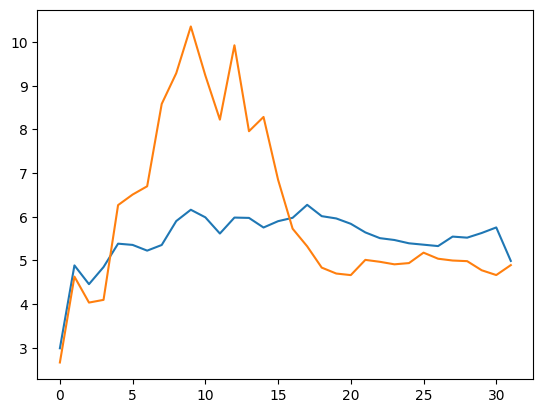

In [129]:
plt.plot(all_dims.mean(-1))
plt.plot(all_dims_shuffled.mean(-1))

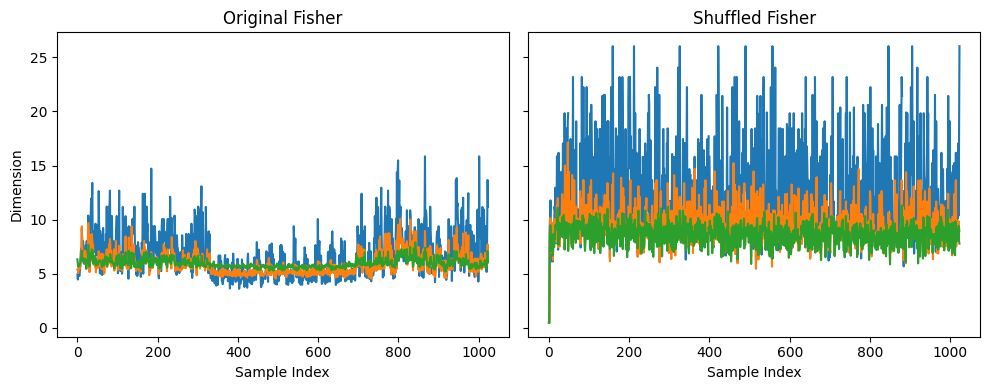

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
data = [dims_fisher, shuffled_dims_fisher]
titles = ['Original Fisher', 'Shuffled Fisher']

for i, (ax, d, title) in enumerate(zip(axes, data, titles)):
    ax.plot(d[2:5].T)
    ax.set_title(title)
    ax.set_xlabel('Sample Index')
    if i == 0:
        ax.set_ylabel('Dimension')
        
plt.tight_layout()
plt.show()

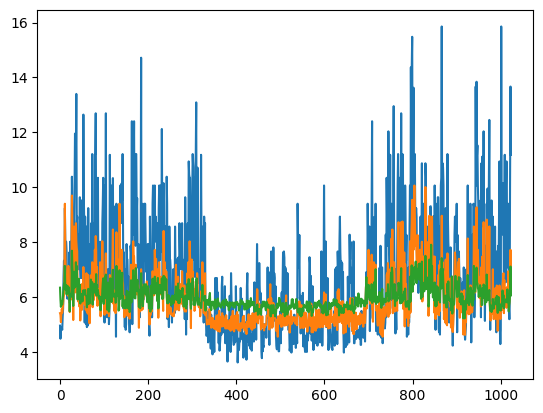

In [108]:
plt.plot(dims_fisher[2:5].T)
plt.plot(shuffled_dims_fisher[2:5].T)

In [98]:
dims_fisher.mean()

6.160914027032084

In [93]:
dims_fisher.mean()

7.49754003526337

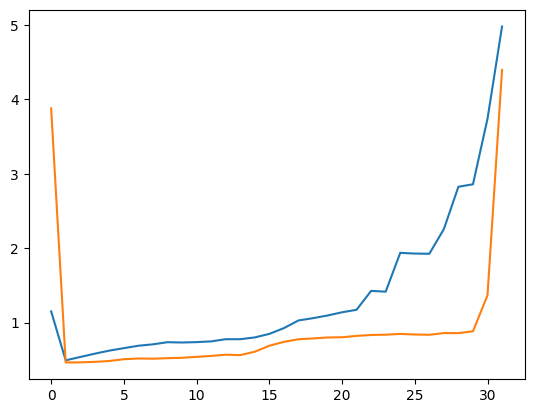

In [71]:
plt.plot(ids)
plt.plot(shuffled_ids)